### 零点计算函数

In [22]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt
from scipy.ndimage import minimum_filter


def compute_zk(
    w_func,
    params=(),
    xlim=(0.0, 20.0),
    ylim=(1e-3, 10.0),
    nx=400,
    ny=300,
    m=4,
    top_candidates=80,
    dedup_tol=1e-5,
    root_tol=1e-10,
    min_imag=1e-8,
):
    """
    Compute the first m dominant complex zeros z_k of w(z)=0 in the upper half-plane.

    Parameters
    ----------
    w_func : callable
        Complex-valued function w(z, *params).
    params : tuple
        Extra parameters passed to w_func.
    xlim : tuple(float, float)
        Search range for Re(z).
    ylim : tuple(float, float)
        Search range for Im(z), upper half-plane only.
    nx, ny : int
        Grid resolution for coarse search.
    m : int
        Number of zeros to return.
    top_candidates : int
        Number of local minima seeds used for refinement.
    dedup_tol : float
        Tolerance for deduplicating roots.
    root_tol : float
        Tolerance for root solver residual.
    min_imag : float
        Minimum positive imaginary part to keep.

    Returns
    -------
    roots : np.ndarray of complex
        Array of shape (<=m,), sorted by Im(z) ascending, then Re(z) ascending.
        These are the "dominant" zeros closest to the real axis.
    """

    def F(v):
        z = v[0] + 1j * v[1]
        wv = w_func(z, *params)
        return np.array([np.real(wv), np.imag(wv)], dtype=float)

    # ---- coarse scan on the upper half-plane ----
    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(xs, ys, indexing="xy")
    Z = X + 1j * Y

    # evaluate |w| on grid
    Wabs = np.empty_like(X, dtype=float)
    for j in range(ny):
        for i in range(nx):
            try:
                val = w_func(Z[j, i], *params)
                Wabs[j, i] = abs(val)
            except Exception:
                Wabs[j, i] = np.inf

    # local minima mask
    local_min = Wabs == minimum_filter(Wabs, size=5, mode="nearest")
    cand_idx = np.argwhere(local_min)

    # sort candidates by |w|
    cand_vals = [(Wabs[j, i], xs[i], ys[j]) for j, i in cand_idx if np.isfinite(Wabs[j, i])]
    cand_vals.sort(key=lambda t: t[0])
    cand_vals = cand_vals[:top_candidates]

    refined_roots = []

    # ---- refine candidates with complex root finder ----
    for _, x0, y0 in cand_vals:
        try:
            sol = root(F, x0=np.array([x0, y0], dtype=float), method="hybr")
            if not sol.success:
                continue

            zr = sol.x[0] + 1j * sol.x[1]

            # keep only upper half-plane
            if np.imag(zr) <= min_imag:
                continue

            # check residual
            res = abs(w_func(zr, *params))
            if not np.isfinite(res) or res > root_tol:
                continue

            refined_roots.append(zr)

        except Exception:
            continue

    # ---- deduplicate roots ----
    unique_roots = []
    for z in refined_roots:
        is_new = True
        for zu in unique_roots:
            if abs(z - zu) < dedup_tol:
                is_new = False
                break
        if is_new:
            unique_roots.append(z)

    # ---- sort by dominance: closest to real axis first ----
    unique_roots.sort(key=lambda z: (np.imag(z), np.real(z)))

    return np.array(unique_roots[:m], dtype=complex)

### 分布函数

TLS parameters: Omega=1.2, Delta=0.8
dominant zeros =
z_1 = 2.5177435491 + 0.1630687443i
z_2 = 5.0354870983 + 0.3261374885i
z_3 = 7.5532306475 + 0.4892062328i
z_4 = 10.0709741966 + 0.6522749771i
z_5 = 12.5887177457 + 0.8153437214i
z_6 = 15.1064612949 + 0.9784124656i
z_7 = 17.6242048440 + 1.1414812099i
z_8 = 20.1419483932 + 1.3045499542i


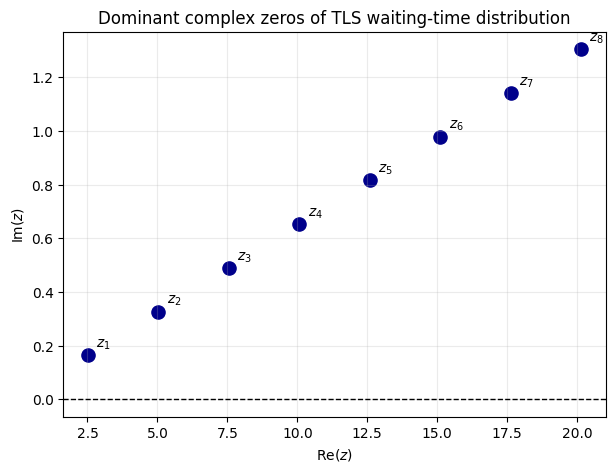

In [23]:
def w_tls_complex(z, Omega, Delta):
    """Complex extension of the TLS waiting-time distribution used in the repo."""
    z = np.asarray(z, dtype=np.complex128)
    Omega = float(Omega)
    Delta = float(Delta)
    eps = 1e-15

    A = np.sqrt((-64.0 * Omega**2 + (1.0 + 4.0 * Delta**2 + 16.0 * Omega**2) ** 2) + 0j)
    if abs(A) < eps:
        A = eps + 0j

    b = np.sqrt((-1.0 + 4.0 * Delta**2 + 16.0 * Omega**2 + A) + 0j) / (2.0 * np.sqrt(2.0))
    c = np.sqrt((1.0 - 4.0 * Delta**2 - 16.0 * Omega**2 + A) + 0j) / (2.0 * np.sqrt(2.0))
    pref = 8.0 * Omega**2 / A

    return pref * (
        -np.exp(-0.5 * z) * np.cos(b * z)
        + 0.5 * (np.exp(-(0.5 - c) * z) + np.exp(-(0.5 + c) * z))
    )

# ---- choose TLS parameters here ----
Omega = 1.2
Delta = 0.8
m_zeros = 8

roots = compute_zk(
    w_tls_complex,
    params=(Omega, Delta),
    xlim=(0.0, 40.0),
    ylim=(1e-3, 20.0),
    nx=600,
    ny=450,
    m=m_zeros,
    top_candidates=150,
    dedup_tol=1e-6,
    root_tol=1e-8,
)

if roots.size == 0:
    raise RuntimeError("No upper-half-plane zeros found. Try enlarging xlim/ylim or changing parameters.")

x = np.real(roots)
y = np.imag(roots)

print(f"TLS parameters: Omega={Omega}, Delta={Delta}")
print("dominant zeros =")
for k, z in enumerate(roots, start=1):
    print(f"z_{k} = {z.real:.10f} + {z.imag:.10f}i")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, s=90, color="darkblue")
for k, zk in enumerate(roots, start=1):
    ax.annotate(f"$z_{k}$", (zk.real, zk.imag), textcoords="offset points", xytext=(6, 6))
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel(r"Re$(z)$")
ax.set_ylabel(r"Im$(z)$")
ax.set_title("Dominant complex zeros of TLS waiting-time distribution")
ax.grid(alpha=0.25)
plt.show()


### 峰模态

In [14]:
def psi(t, xk, yk):
    return 1.0 / ((t - xk)**2 + yk**2)

### 相互作用矩阵

In [15]:
import numpy as np

def psi(t, xk, yk):
    t = np.asarray(t, dtype=float)
    return 1.0 / ((t - xk)**2 + yk**2)

def compute_waiting_time_real(tau, Omega, Delta, eps=1e-300):
    tau = np.asarray(tau, dtype=float)
    Omega = float(Omega)
    Delta = float(Delta)

    a_sq = -64.0 * Omega**2 + (1.0 + 4.0 * Delta**2 + 16.0 * Omega**2) ** 2
    A = np.sqrt(np.maximum(a_sq, 0.0))
    A = np.maximum(A, 1e-300)

    b_sq = -1.0 + 4.0 * Delta**2 + 16.0 * Omega**2 + A
    c_sq = 1.0 - 4.0 * Delta**2 - 16.0 * Omega**2 + A
    b = np.sqrt(np.maximum(b_sq, 0.0)) / (2.0 * np.sqrt(2.0))
    c = np.sqrt(np.maximum(c_sq, 0.0)) / (2.0 * np.sqrt(2.0))

    pref = 8.0 * Omega**2 / A
    term_cos = np.exp(-0.5 * tau) * np.cos(b * tau)
    term_cosh = 0.5 * (np.exp(-(0.5 - c) * tau) + np.exp(-(0.5 + c) * tau))
    w_tau = pref * (-term_cos + term_cosh)
    return np.where(np.isfinite(w_tau) & (w_tau > eps), w_tau, eps)

def fisher_density_trace(tau, Omega, Delta, h_delta=1e-4, h_omega=1e-4, eps_w=1e-300):
    tau = np.asarray(tau, dtype=float)
    w0 = compute_waiting_time_real(tau, Omega=Omega, Delta=Delta, eps=eps_w)
    w_dp = compute_waiting_time_real(tau, Omega=Omega, Delta=Delta + h_delta, eps=eps_w)
    w_dm = compute_waiting_time_real(tau, Omega=Omega, Delta=Delta - h_delta, eps=eps_w)
    w_op = compute_waiting_time_real(tau, Omega=Omega + h_omega, Delta=Delta, eps=eps_w)
    w_om = compute_waiting_time_real(tau, Omega=Omega - h_omega, Delta=Delta, eps=eps_w)

    dw_dDelta = (w_dp - w_dm) / (2.0 * h_delta)
    dw_dOmega = (w_op - w_om) / (2.0 * h_omega)
    return (dw_dDelta**2 + dw_dOmega**2) / np.maximum(w0, eps_w)

def compute_W(x, y, Omega, Delta, n_grid=20000):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = len(x)
    W = np.zeros((m, m), dtype=float)
    Tmax = float(np.max(x) + 20.0 * np.max(y))
    tau = np.linspace(0.0, Tmax, int(n_grid), dtype=float)
    phi = np.stack([psi(tau, xk, yk) for xk, yk in zip(x, y)], axis=0)
    rho_f = fisher_density_trace(tau, Omega=Omega, Delta=Delta)

    for k in range(m):
        for l in range(k, m):
            val = np.trapz(phi[k] * phi[l] * rho_f, tau)
            W[k, l] = val
            W[l, k] = val
    return W

### 归一化矩阵

In [17]:
def normalize_W(W):
    d = np.sqrt(np.diag(W))
    Wn = W / (d[:, None] * d[None, :])
    return Wn

### 阈值图

In [18]:
def threshold_graph(Wn, eps):
    A = (Wn >= eps).astype(int)
    np.fill_diagonal(A, 0)
    return A

### 连通分支数

In [19]:
def num_components(A):
    n = A.shape[0]
    visited = [False] * n
    count = 0

    for i in range(n):
        if not visited[i]:
            count += 1
            stack = [i]
            visited[i] = True
            while stack:
                u = stack.pop()
                for v in range(n):
                    if A[u, v] and not visited[v]:
                        visited[v] = True
                        stack.append(v)
    return count

### 最大连通块大小

In [20]:
def largest_component_size(A):
    n = A.shape[0]
    visited = [False] * n
    best = 0

    for i in range(n):
        if not visited[i]:
            stack = [i]
            visited[i] = True
            size = 0
            while stack:
                u = stack.pop()
                size += 1
                for v in range(n):
                    if A[u, v] and not visited[v]:
                        visited[v] = True
                        stack.append(v)
            best = max(best, size)
    return best

### 扫阈值

Using Fisher-weighted interaction matrix: $W_{kl}^{(F)} = \int \psi_k(\tau)\psi_l(\tau)\,\mathrm{tr}(I_\tau)\,d\tau$
off-diagonal Wn statistics:
min=0.024930, q10=0.037182, q25=0.063851, median=0.117931, q75=0.186243, q90=0.332211, max=0.527871


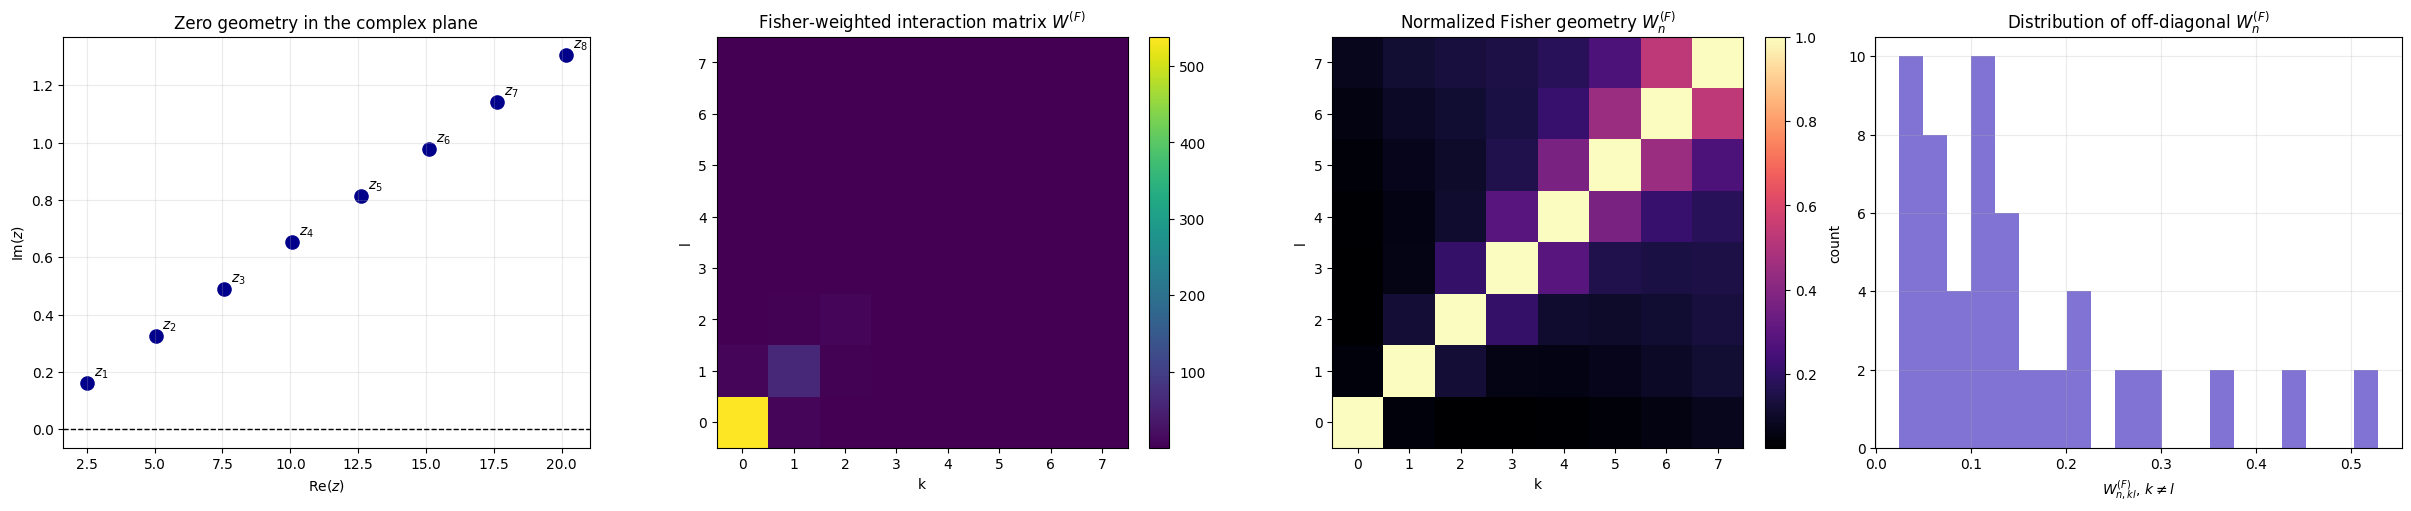

eps=0.527872, edges=0, beta0=8, largest=1
eps=0.527871, edges=0, beta0=8, largest=1
eps=0.451517, edges=1, beta0=7, largest=2
eps=0.373335, edges=2, beta0=6, largest=3
eps=0.291088, edges=3, beta0=5, largest=4
eps=0.262843, edges=4, beta0=4, largest=5
eps=0.211988, edges=6, beta0=4, largest=5
eps=0.205186, edges=6, beta0=4, largest=5
eps=0.179929, edges=7, beta0=3, largest=6
eps=0.161898, edges=8, beta0=3, largest=6
eps=0.150104, edges=9, beta0=3, largest=6
eps=0.143677, edges=10, beta0=3, largest=6
eps=0.136318, edges=12, beta0=3, largest=6
eps=0.120923, edges=12, beta0=3, largest=6
eps=0.119893, edges=13, beta0=2, largest=7
eps=0.115968, edges=15, beta0=2, largest=7
eps=0.111498, edges=15, beta0=2, largest=7
eps=0.103980, edges=17, beta0=2, largest=7
eps=0.094488, edges=17, beta0=2, largest=7
eps=0.079034, edges=19, beta0=1, largest=8
eps=0.074586, edges=19, beta0=1, largest=8
eps=0.064312, edges=20, beta0=1, largest=8
eps=0.062468, edges=22, beta0=1, largest=8
eps=0.058988, edges=22

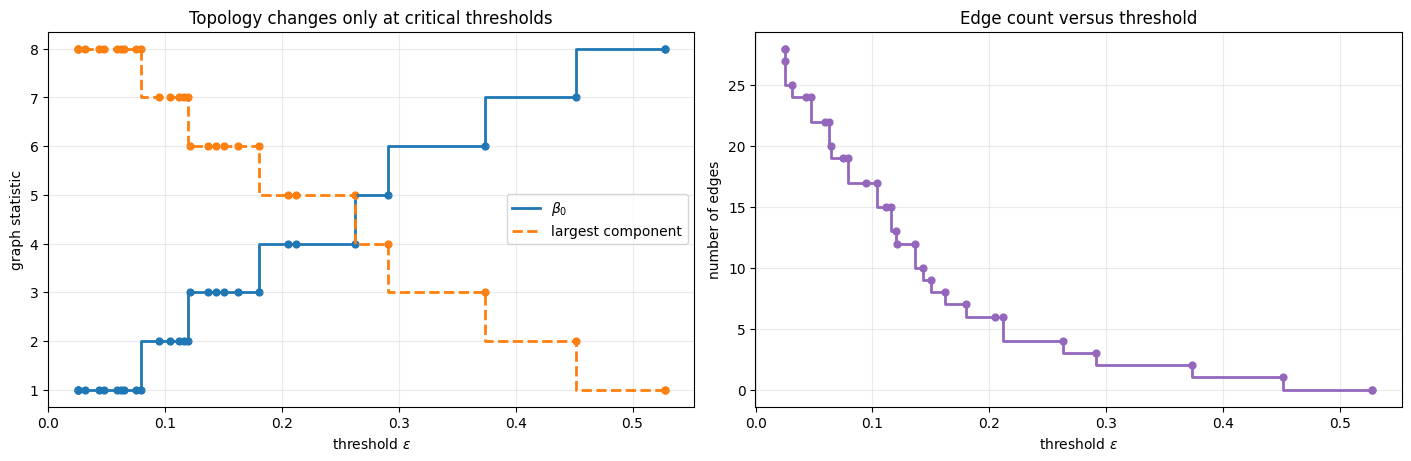

In [21]:
W = compute_W(x, y, Omega=Omega, Delta=Delta)
print(r"Using Fisher-weighted interaction matrix: $W_{kl}^{(F)} = \int \psi_k(\tau)\psi_l(\tau)\,\mathrm{tr}(I_\tau)\,d\tau$")
Wn = normalize_W(W)

offdiag_mask = ~np.eye(Wn.shape[0], dtype=bool)
offdiag_vals = Wn[offdiag_mask]
offdiag_vals = offdiag_vals[np.isfinite(offdiag_vals)]

if offdiag_vals.size == 0:
    raise RuntimeError("No finite off-diagonal entries in Wn.")

q = np.quantile(offdiag_vals, [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
print("off-diagonal Wn statistics:")
print(f"min={q[0]:.6f}, q10={q[1]:.6f}, q25={q[2]:.6f}, median={q[3]:.6f}, q75={q[4]:.6f}, q90={q[5]:.6f}, max={q[6]:.6f}")

# Topology changes only when epsilon crosses an actual edge weight.
# Scan those critical thresholds directly instead of a coarse linspace.
critical_eps = np.unique(np.round(offdiag_vals, 10))
critical_eps = np.sort(critical_eps)[::-1]
delta_eps = 1e-6

if critical_eps.size == 1:
    eps_list = np.array([
        min(0.999999, float(critical_eps[0]) + delta_eps),
        float(critical_eps[0]),
        max(0.0, float(critical_eps[0]) - delta_eps),
    ])
else:
    eps_list = np.concatenate((
        [min(0.999999, float(critical_eps[0]) + delta_eps)],
        critical_eps,
        [max(0.0, float(critical_eps[-1]) - delta_eps)],
    ))

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

axes[0].scatter(x, y, s=90, color="darkblue")
for k, (xk, yk) in enumerate(zip(x, y), start=1):
    axes[0].annotate(f"$z_{k}$", (xk, yk), textcoords="offset points", xytext=(5, 5))
axes[0].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[0].set_xlabel(r"Re$(z)$")
axes[0].set_ylabel(r"Im$(z)$")
axes[0].set_title("Zero geometry in the complex plane")
axes[0].grid(alpha=0.25)

im1 = axes[1].imshow(W, cmap="viridis", origin="lower")
axes[1].set_title("Fisher-weighted interaction matrix $W^{(F)}$")
axes[1].set_xlabel("k")
axes[1].set_ylabel("l")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(Wn, cmap="magma", origin="lower", vmin=float(np.min(Wn)), vmax=float(np.max(Wn)))
axes[2].set_title("Normalized Fisher geometry $W_n^{(F)}$")
axes[2].set_xlabel("k")
axes[2].set_ylabel("l")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].hist(offdiag_vals, bins=min(20, max(5, offdiag_vals.size // 2)), color="slateblue", alpha=0.85)
axes[3].set_title("Distribution of off-diagonal $W_n^{(F)}$")
axes[3].set_xlabel(r"$W_{n,kl}^{(F)}$, $k \neq l$")
axes[3].set_ylabel("count")
axes[3].grid(alpha=0.25)
plt.show()

beta0_list = []
largest_list = []
edge_count_list = []
for eps in eps_list:
    A = threshold_graph(Wn, eps)
    beta0 = num_components(A)
    M = largest_component_size(A)
    edge_count = int(np.sum(A) // 2)
    beta0_list.append(beta0)
    largest_list.append(M)
    edge_count_list.append(edge_count)
    print(f"eps={eps:.6f}, edges={edge_count}, beta0={beta0}, largest={M}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].step(eps_list, beta0_list, where="post", linewidth=2.0, label=r"$\beta_0$")
axes[0].step(eps_list, largest_list, where="post", linewidth=2.0, linestyle="--", label="largest component")
axes[0].scatter(eps_list, beta0_list, s=24)
axes[0].scatter(eps_list, largest_list, s=24)
axes[0].set_xlabel(r"threshold $\epsilon$")
axes[0].set_ylabel("graph statistic")
axes[0].set_title("Topology changes only at critical thresholds")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].step(eps_list, edge_count_list, where="post", linewidth=2.0, color="tab:purple")
axes[1].scatter(eps_list, edge_count_list, s=24, color="tab:purple")
axes[1].set_xlabel(r"threshold $\epsilon$")
axes[1].set_ylabel("number of edges")
axes[1].set_title("Edge count versus threshold")
axes[1].grid(alpha=0.25)

plt.show()


### Fisher诱导距离与 persistent homology

In [ ]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from tools.tools import (
    similarity_to_distance,
    vietoris_rips_persistence,
    persistence_summary,
    plot_persistence_barcodes,
    plot_persistence_diagrams,
    noniid_three_level_determinant_complex,
    noniid_three_level_aggregated_waiting_time_real,
    compute_weighted_interaction_matrix,
    normalize_interaction_matrix,
)

def print_persistence_summary(summary, label):
    print(f"Persistence summary for {label}:")
    for dim in sorted(summary):
        stats = summary[dim]
        print(
            f"  H_{dim}: total={stats['count_total']}, finite={stats['count_finite']}, "
            f"infinite={stats['count_infinite']}"
        )
        for rank, bar in enumerate(stats['top_finite'], start=1):
            print(
                f"    top{rank}: birth={bar['birth']:.6f}, death={bar['death']:.6f}, "
                f"lifetime={bar['lifetime']:.6f}, simplex={bar['simplex']}"
            )

D_tls = similarity_to_distance(Wn)
diag_tls = vietoris_rips_persistence(D_tls, max_dim=2, backend="auto")
summary_tls = persistence_summary(diag_tls, max_dim=1, top_k=5)
print_persistence_summary(summary_tls, label="TLS Fisher geometry")
print("PH backend: ripser if available, otherwise internal fallback.")

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), constrained_layout=True)
im = ax.imshow(D_tls, cmap="cividis", origin="lower")
ax.set_title("TLS Fisher-induced distance $D_F$")
ax.set_xlabel("k")
ax.set_ylabel("l")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_persistence_barcodes(diag_tls, max_dim=1, title="TLS Fisher persistent homology")
plot_persistence_diagrams(diag_tls, max_dim=1, title="TLS Fisher persistence diagram")
plt.show()


### 带 shelving 的三能级系统

In [ ]:
# Nonrenewal shelving model: use the kernel determinant det(I-K(z)).
# The stationary marginal below is only a one-interval diagnostic.
delta_sh = 0.8
omega_sh = 1.2
gamma_bg_sh = 1.0
gamma_es_sh = 0.18
gamma_sg_sh = 0.045
delta_s_sh = 0.0
m_zeros_sh = 8

roots_sh = compute_zk(
    noniid_three_level_determinant_complex,
    params=(delta_sh, omega_sh, gamma_bg_sh, gamma_es_sh, gamma_sg_sh, delta_s_sh, "shelving"),
    xlim=(0.0, 60.0),
    ylim=(1e-3, 20.0),
    nx=520,
    ny=380,
    m=m_zeros_sh,
    top_candidates=120,
    dedup_tol=1e-6,
    root_tol=1e-8,
)

if roots_sh.size == 0:
    raise RuntimeError("No shelving roots found. Try enlarging xlim/ylim or changing parameters.")

x_sh = np.real(roots_sh)
y_sh = np.imag(roots_sh)

print(
    "Shelving parameters:",
    {
        "delta": delta_sh,
        "omega": omega_sh,
        "gamma_bg": gamma_bg_sh,
        "gamma_es": gamma_es_sh,
        "gamma_sg": gamma_sg_sh,
        "delta_s": delta_s_sh,
    },
)
print("dominant shelving zeros =")
for k, z in enumerate(roots_sh, start=1):
    print(f"z_{k} = {z.real:.10f} + {z.imag:.10f}i")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_sh, y_sh, s=90, color="darkred")
for k, zk in enumerate(roots_sh, start=1):
    ax.annotate(f"$z_{k}$", (zk.real, zk.imag), textcoords="offset points", xytext=(6, 6))
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xlabel(r"Re$(z)$")
ax.set_ylabel(r"Im$(z)$")
ax.set_title("Dominant zeros of the shelving three-level waiting-time distribution")
ax.grid(alpha=0.25)
plt.show()


In [ ]:
t_max_sh = float(np.max(x_sh) + 20.0 * np.max(y_sh))
tau_sh = np.linspace(0.0, t_max_sh, 12000, dtype=float)
rho_f_sh = noniid_three_level_aggregated_waiting_time_real(
    tau_sh,
    delta=delta_sh,
    omega=omega_sh,
    gamma_bg=gamma_bg_sh,
    gamma_es=gamma_es_sh,
    gamma_sg=gamma_sg_sh,
    delta_s=delta_s_sh,
    scheme="shelving",
)
W_sh = compute_weighted_interaction_matrix(x_sh, y_sh, tau_sh, rho_f_sh)
Wn_sh = normalize_interaction_matrix(W_sh)
D_sh = similarity_to_distance(Wn_sh)

offdiag_mask_sh = ~np.eye(Wn_sh.shape[0], dtype=bool)
offdiag_vals_sh = Wn_sh[offdiag_mask_sh]
offdiag_vals_sh = offdiag_vals_sh[np.isfinite(offdiag_vals_sh)]
q_sh = np.quantile(offdiag_vals_sh, [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
print("off-diagonal shelving Wn statistics:")
print(f"min={q_sh[0]:.6f}, q10={q_sh[1]:.6f}, q25={q_sh[2]:.6f}, median={q_sh[3]:.6f}, q75={q_sh[4]:.6f}, q90={q_sh[5]:.6f}, max={q_sh[6]:.6f}")

critical_eps_sh = np.unique(np.round(offdiag_vals_sh, 10))
critical_eps_sh = np.sort(critical_eps_sh)[::-1]
delta_eps = 1e-6
if critical_eps_sh.size == 1:
    eps_list_sh = np.array([
        min(0.999999, float(critical_eps_sh[0]) + delta_eps),
        float(critical_eps_sh[0]),
        max(0.0, float(critical_eps_sh[0]) - delta_eps),
    ])
else:
    eps_list_sh = np.concatenate((
        [min(0.999999, float(critical_eps_sh[0]) + delta_eps)],
        critical_eps_sh,
        [max(0.0, float(critical_eps_sh[-1]) - delta_eps)],
    ))

diag_sh = vietoris_rips_persistence(D_sh, max_dim=2, backend="auto")
summary_sh = persistence_summary(diag_sh, max_dim=1, top_k=5)
print_persistence_summary(summary_sh, label="shelving Fisher geometry")
print("PH backend: ripser if available, otherwise internal fallback.")

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
axes[0].scatter(x_sh, y_sh, s=90, color="darkred")
for k, (xk, yk) in enumerate(zip(x_sh, y_sh), start=1):
    axes[0].annotate(f"$z_{k}$", (xk, yk), textcoords="offset points", xytext=(5, 5))
axes[0].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[0].set_xlabel(r"Re$(z)$")
axes[0].set_ylabel(r"Im$(z)$")
axes[0].set_title("Shelving zero geometry")
axes[0].grid(alpha=0.25)

im1 = axes[1].imshow(W_sh, cmap="viridis", origin="lower")
axes[1].set_title("Shelving Fisher-weighted $W^{(F)}$")
axes[1].set_xlabel("k")
axes[1].set_ylabel("l")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(Wn_sh, cmap="magma", origin="lower", vmin=float(np.min(Wn_sh)), vmax=float(np.max(Wn_sh)))
axes[2].set_title("Shelving normalized Fisher geometry $W_n^{(F)}$")
axes[2].set_xlabel("k")
axes[2].set_ylabel("l")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

axes[3].hist(offdiag_vals_sh, bins=min(20, max(5, offdiag_vals_sh.size // 2)), color="firebrick", alpha=0.85)
axes[3].set_title("Shelving off-diagonal $W_n^{(F)}$")
axes[3].set_xlabel(r"$W_{n,kl}^{(F)}$, $k \neq l$")
axes[3].set_ylabel("count")
axes[3].grid(alpha=0.25)
plt.show()

beta0_list_sh = []
largest_list_sh = []
for eps in eps_list_sh:
    A_sh = threshold_graph(Wn_sh, eps)
    beta0_list_sh.append(num_components(A_sh))
    largest_list_sh.append(largest_component_size(A_sh))
    print(f"eps={eps:.6f}, edges={int(np.sum(A_sh)//2)}, beta0={beta0_list_sh[-1]}, largest={largest_list_sh[-1]}")

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), constrained_layout=True)
ax.step(eps_list_sh, beta0_list_sh, where="post", linewidth=2.0, label=r"$\beta_0$")
ax.step(eps_list_sh, largest_list_sh, where="post", linewidth=2.0, linestyle="--", label="largest component")
ax.scatter(eps_list_sh, beta0_list_sh, s=24)
ax.scatter(eps_list_sh, largest_list_sh, s=24)
ax.set_xlabel(r"threshold $\epsilon$")
ax.set_ylabel("graph statistic")
ax.set_title("Shelving graph topology across thresholds")
ax.grid(alpha=0.25)
ax.legend()

plot_persistence_barcodes(diag_sh, max_dim=1, title="Shelving Fisher persistent homology")
plot_persistence_diagrams(diag_sh, max_dim=1, title="Shelving Fisher persistence diagram")
plt.show()
